**Text Lead**

Input: `01_Processed_Data/metadata.csv` + `01_Processed_Data/lyrics/*.txt` from Data Lead (notebook 01).

Output (saved to `02_Embeddings/` and `03_Final_Results/`):
- `02_Embeddings/text_ib_embeddings.npy` — ImageBind Text (generalist), shape `(150, 1024)`, float32
- `02_Embeddings/text_clap_embeddings.npy` — CLAP HTSAT-tiny text (audio-text specialist), shape `(150, 512)`, float32
- `03_Final_Results/sentiment_results.csv` — per-track top-5 GoEmotions labels and scores
- `03_Final_Results/lyric_lengths.csv` — per-track character and word counts

Goal: extract the "emotional vocabulary" of each song's lyrics via generalist (ImageBind) and specialist (CLAP) text encoders, plus multi-label emotion classification.


Run all once data processing is complete.

**Caveat — lyric length sensitivity.** CLAP reuses CLIP's text encoder, which truncates at **77 tokens** (~300 characters of English prose). Tracks with very short lyrics (<50 words) therefore produce degraded CLAP embeddings. This notebook operationalizes the caveat:

- per-track lengths are logged to `03_Final_Results/lyric_lengths.csv`
- a warning is printed for any track with `<50 words`
- a lyric-length histogram (with the 50-word threshold marked) is saved to this notebook's visual-checks folder

Notebook 06 can use `lyric_lengths.csv` to caveat UMAP plots for short-lyric tracks.


In [ ]:
# 1. Connect to Google Drive & Core Imports
from google.colab import drive
import os, shutil, random, re
from datetime import datetime
import pandas as pd
import numpy as np
import torch

drive.mount('/content/drive')

# 2. Canonical project paths
PROJECT_ROOT = "/content/drive/MyDrive/DL_Project_2026"

PROCESSED_DIR  = os.path.join(PROJECT_ROOT, "01_Processed_Data")
EMBED_DIR      = os.path.join(PROJECT_ROOT, "02_Embeddings")
RESULTS_DIR    = os.path.join(PROJECT_ROOT, "03_Final_Results")
VIS_DIR        = os.path.join(PROJECT_ROOT, "04_Visual_Checks")
VERSIONS_ROOT  = os.path.join(PROJECT_ROOT, "99_Versions")

NOTEBOOK_ID = "04"

for d in (EMBED_DIR, RESULTS_DIR, VIS_DIR, VERSIONS_ROOT):
    os.makedirs(d, exist_ok=True)

# 3. Seed everything
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# 4. Archive primitives (shared signature across all six notebooks)
def archive_previous_run(directory_path, notebook_id):
    if os.path.exists(directory_path) and os.listdir(directory_path):
        stamp = datetime.now().strftime("%Y-%m-%d_%H-%M")
        folder_name = os.path.basename(directory_path)
        archive_name = os.path.join(VERSIONS_ROOT, f"{notebook_id}_{stamp}_{folder_name}")
        os.makedirs(VERSIONS_ROOT, exist_ok=True)
        print(f"📦 Archiving previous {folder_name} to: {archive_name}")
        shutil.move(directory_path, archive_name)
    os.makedirs(directory_path, exist_ok=True)

def archive_files(file_paths, notebook_id):
    movers = [p for p in file_paths if os.path.exists(p)]
    if not movers:
        return
    stamp = datetime.now().strftime("%Y-%m-%d_%H-%M")
    parent_name = os.path.basename(os.path.dirname(movers[0]))
    out_dir = os.path.join(VERSIONS_ROOT, f"{notebook_id}_{stamp}_{parent_name}")
    os.makedirs(out_dir, exist_ok=True)
    for p in movers:
        shutil.move(p, os.path.join(out_dir, os.path.basename(p)))
    print(f"📦 Archived {len(movers)} file(s) to {out_dir}")

# 5. Device check + fallback warning
device = "cuda" if torch.cuda.is_available() else "cpu"
if device == "cpu":
    print("⚠️  Running on CPU — ImageBind + RoBERTa + CLAP on 150 tracks will be very slow.")
    print("    Fix: Runtime → Change runtime type → GPU.")
else:
    props = torch.cuda.get_device_properties(0)
    print(f"✅ Device: {device} | {torch.cuda.get_device_name(0)} | {props.total_memory / 1e9:.1f} GB")

print(f"✅ Notebook {NOTEBOOK_ID} setup complete.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Device: cuda | Tesla T4 | 15.6 GB
✅ Notebook 04 setup complete.


In [ ]:
# --- UPSTREAM CONTRACT CHECK (notebook 01 must have run) ---
metadata_path = os.path.join(PROCESSED_DIR, "metadata.csv")
assert os.path.exists(metadata_path), f"metadata.csv not found at {metadata_path}. Run notebook 01 first."

metadata = pd.read_csv(metadata_path)

REQUIRED_COLS = [
    "track_id", "file_name", "song_title", "artist_name", "genre",
    "emotion_category", "emotion_subcategory", "contributor",
    "standardized_audio_path", "standardized_image_path", "lyrics_path",
]
missing_cols = [c for c in REQUIRED_COLS if c not in metadata.columns]
assert not missing_cols, f"metadata.csv missing columns {missing_cols} — rerun notebook 01."
assert metadata["track_id"].is_unique, "Duplicate track_id in metadata.csv"

lyric_paths = [os.path.join(PROCESSED_DIR, "lyrics", f"{tid}.txt") for tid in metadata["track_id"]]
missing_lyrics = [p for p in lyric_paths if not os.path.exists(p)]
assert not missing_lyrics, f"Missing {len(missing_lyrics)} lyric files (first: {missing_lyrics[:3]}) — rerun notebook 01."

print(f"✅ Upstream contract OK — {len(metadata)} tracks ready for text embedding.")


✅ Upstream contract OK — 150 tracks ready for text embedding.


In [ ]:
# --- STEP 1: INSTALL SPECIALIZED TOOLS ---
# The hard problem here: laion_clap (via librosa) and fvcore/iopath/pytorchvideo
# all pin numpy<2.0. When we pip install them, numpy gets downgraded ON DISK to
# 1.26.4, but the already-loaded IN-MEMORY numpy in Colab's kernel is still
# 2.0.2. Any later attribute access on numpy (or importlib.import_module on one
# of its submodules) scans numpy.__path__ → hits 1.26.4 files → sanity
# check fails → crashes with the misleading message "ModuleNotFoundError:
# No module named 'numpy.char'".
#
# There is no fix that keeps numpy 2.0.2 given this dep stack. The reliable
# path is: let the install downgrade numpy to 1.26.4, detect the mismatch,
# and ask the user to restart the runtime once. After restart, in-memory numpy
# matches on-disk (1.26.4), numpy.char works natively as a real submodule
# (numpy 1.x ships it that way), and everything downstream is fine.
#
# Expect large downloads on first run: ImageBind huge ~4.5 GB, CLAP HTSAT-tiny
# ~100 MB, RoBERTa go_emotions ~500 MB.
!pip install -q laion_clap
!pip install -q -U "transformers>=4.46,<5.0"
!pip install -q --no-deps git+https://github.com/facebookresearch/ImageBind.git
!pip install -q pytorchvideo timm einops ftfy regex iopath fvcore

# --- Critical: detect numpy version mismatch (in-memory vs on-disk) ---
# This must run BEFORE any attribute access on numpy (like `np.char`), because
# the lazy attribute lookup is what triggers the crash when the versions have
# drifted apart.
import importlib.metadata as _md
import numpy as _np_check
_ondisk_np   = _md.version("numpy")
_inmemory_np = _np_check.__version__
if _ondisk_np != _inmemory_np:
    raise RuntimeError(
        "\n\n"
        "⚠️  numpy downgrade detected.\n"
        f"   in-memory numpy: {_inmemory_np}  (what the kernel loaded at boot)\n"
        f"   on-disk  numpy: {_ondisk_np}  (what the installs left)\n\n"
        "   Colab caches numpy in memory, so the downgrade leaves it in a corrupted\n"
        "   state that crashes transformers' BertModel import with the misleading\n"
        "   message 'No module named numpy.char'.\n\n"
        "   FIX: Runtime → Restart runtime → Runtime → Run all (or re-run\n"
        f"   from Cell 1). On the second pass, numpy {_ondisk_np} loads cleanly from\n"
        "   disk, in-memory matches on-disk, and Cell 5 succeeds. This is a\n"
        "   one-time tax per fresh Colab session — subsequent runs in the same\n"
        "   session will skip this check because numpy is already 1.26.4 on disk.\n"
    )

# Version assertion for transformers (only reaches here if numpy is healthy)
import transformers as _tf_check
_tf_major, _tf_minor = (int(x) for x in _tf_check.__version__.split(".")[:2])
assert (4, 46) <= (_tf_major, _tf_minor) < (5, 0), (
    f"transformers {_tf_check.__version__} outside tested range (4.46 — 4.x). "
    "Restart the runtime and re-run from Cell 2."
)

# Belt-and-suspenders: ensure numpy.char is in sys.modules (in case some edge
# case reintroduces the importlib path). Accesses via internal module so we
# don't risk the lazy-attribute path that was failing before.
import sys as _sys
try:
    import numpy._core.defchararray as _np_char_impl  # numpy 2.x
except ImportError:
    import numpy.core.defchararray as _np_char_impl   # numpy 1.x
_sys.modules.setdefault("numpy.char", _np_char_impl)

print(
    f"✅ numpy {_np_check.__version__} (in-memory matches on-disk) + "
    f"transformers {_tf_check.__version__} — import path is safe."
)

import laion_clap
from transformers import pipeline

# --- Workaround: pytorchvideo 0.1.5 imports torchvision.transforms.functional_tensor,
# which was made private in torchvision 0.17 and removed in later versions. Shim it to
# the public torchvision.transforms.functional module (compatible signatures). Must be
# registered before `from imagebind import data`. ---
import sys as _sys2
import torchvision.transforms.functional as _tvf
_sys2.modules.setdefault("torchvision.transforms.functional_tensor", _tvf)

from imagebind import data as ib_data
from imagebind.models import imagebind_model
from imagebind.models.imagebind_model import ModalityType

# --- STEP 2: LOAD MODELS ---
print("🎸 Loading CLAP HTSAT-tiny (audio-text specialist) ...")
clap_model = laion_clap.CLAP_Module(enable_fusion=False, amodel='HTSAT-tiny')
clap_model.load_ckpt()          # default checkpoint; pinning deferred (ASK A-1)
clap_model = clap_model.to(device)
clap_model.eval()

print("📜 Loading RoBERTa GoEmotions sentiment + ImageBind huge ...")
# top_k=None preserves the full 28-label multi-label distribution
sentiment_pipe = pipeline(
    "text-classification",
    model="SamLowe/roberta-base-go_emotions",
    top_k=None,
    device=0 if device == "cuda" else -1,
)
ib_model = imagebind_model.imagebind_huge(pretrained=True).to(device).eval()

# --- STEP 3: READ LYRICS + MEASURE LENGTHS ---
lyric_texts, length_rows = [], []
for tid in metadata['track_id']:
    with open(os.path.join(PROCESSED_DIR, "lyrics", f"{tid}.txt"), "r", encoding="utf-8") as f:
        text = f.read()
    # NOTE: we intentionally do NOT character-truncate here.
    #       Notebook 01 already caps lyrics at 1000 chars; letting each model's
    #       tokenizer own its own truncation (RoBERTa: 512 tokens, CLAP: 77 tokens).
    lyric_texts.append(text)
    n_chars = len(text)
    n_words = len(re.findall(r"\b\w+\b", text))
    length_rows.append({"track_id": tid, "n_chars": n_chars, "n_words": n_words})

lyric_stats = pd.DataFrame(length_rows)
short_tracks = lyric_stats[lyric_stats["n_words"] < 50]
if len(short_tracks) > 0:
    print(f"⚠️  {len(short_tracks)} tracks have <50 words — CLAP signal will be weak:")
    print(short_tracks.to_string(index=False))

# --- STEP 4: BATCHED SENTIMENT (multi-label top-5 per track) ---
print(f"🧠 Sentiment: batched top-5 over {len(lyric_texts)} lyrics ...")
# With top_k=None, each result is a list of {label, score} dicts (sorted by score desc).
all_scores = sentiment_pipe(
    lyric_texts,
    batch_size=16,
    truncation=True,
    max_length=512,     # RoBERTa tokenizer will cap here
)

sentiment_rows = []
for tid, scores in zip(metadata["track_id"], all_scores):
    row = {"track_id": tid}
    for k, s in enumerate(scores[:5]):
        row[f"top{k+1}_label"] = s["label"]
        row[f"top{k+1}_score"] = float(s["score"])
    sentiment_rows.append(row)
sentiment_df = pd.DataFrame(sentiment_rows)

# --- STEP 5: EXTRACT TEXT EMBEDDINGS ---
print("🎨 ImageBind Text ...")
ib_text_tensor = ib_data.load_and_transform_text(lyric_texts, device)
with torch.no_grad():
    ib_out = ib_model({ModalityType.TEXT: ib_text_tensor})
text_ib = ib_out[ModalityType.TEXT].detach().cpu().numpy().astype(np.float32)
print(f"   ImageBind text: {text_ib.shape}")

print("🎶 CLAP Text ...")
with torch.no_grad():
    # CLAP's own tokenizer truncates at 77 tokens (CLIP-style).
    text_clap_raw = clap_model.get_text_embedding(lyric_texts)
text_clap = np.asarray(text_clap_raw, dtype=np.float32)
print(f"   CLAP text:      {text_clap.shape}")

# --- STEP 6: SHAPE / FINITE / DTYPE ASSERTIONS ---
EXPECTED_IB_DIM = 1024
EXPECTED_CLAP_DIM = 512
N = len(metadata)

assert text_ib.shape == (N, EXPECTED_IB_DIM), f"text_ib wrong shape: {text_ib.shape}"
assert text_clap.shape == (N, EXPECTED_CLAP_DIM), f"text_clap wrong shape: {text_clap.shape}"
assert text_ib.dtype == np.float32 and text_clap.dtype == np.float32
assert np.isfinite(text_ib).all(), "text_ib contains NaN/Inf"
assert np.isfinite(text_clap).all(), "text_clap contains NaN/Inf"

# --- STEP 7: ARCHIVE (file-scoped) THEN SAVE EMBEDDINGS ---
text_ib_path   = os.path.join(EMBED_DIR, "text_ib_embeddings.npy")
text_clap_path = os.path.join(EMBED_DIR, "text_clap_embeddings.npy")

archive_files([text_ib_path, text_clap_path], notebook_id=NOTEBOOK_ID)

np.save(text_ib_path,   text_ib)
np.save(text_clap_path, text_clap)
# NOTE: vectors saved UN-normalized; notebook 05 handles L2 normalization before cosine.

print(f"✅ Saved {text_ib_path}  {text_ib.shape}")
print(f"✅ Saved {text_clap_path} {text_clap.shape}")

# --- STEP 8: ARCHIVE + SAVE CSVs (RESULTS_DIR) ---
sentiment_csv_path     = os.path.join(RESULTS_DIR, "sentiment_results.csv")
lyric_lengths_csv_path = os.path.join(RESULTS_DIR, "lyric_lengths.csv")

archive_files([sentiment_csv_path, lyric_lengths_csv_path], notebook_id=NOTEBOOK_ID)
os.makedirs(RESULTS_DIR, exist_ok=True)

sentiment_df.to_csv(sentiment_csv_path, index=False)
lyric_stats.to_csv(lyric_lengths_csv_path, index=False)

print(f"✅ Saved {sentiment_csv_path} (columns: {list(sentiment_df.columns)})")
print(f"✅ Saved {lyric_lengths_csv_path} (columns: {list(lyric_stats.columns)})")


  Preparing metadata (setup.py) ... done
✅ numpy 1.26.4 (in-memory matches on-disk) + transformers 4.57.6 — import path is safe.
🎸 Loading CLAP HTSAT-tiny (audio-text specialist) ...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Load our best checkpoint in the paper.
The checkpoint is already downloaded
Load Checkpoint...
logit_scale_a 	 Loaded
logit_scale_t 	 Loaded
audio_branch.spectrogram_extractor.stft.conv_real.weight 	 Loaded
audio_branch.spectrogram_extractor.stft.conv_imag.weight 	 Loaded
audio_branch.logmel_extractor.melW 	 Loaded
audio_branch.bn0.weight 	 Loaded
audio_branch.bn0.bias 	 Loaded
audio_branch.patch_embed.proj.weight 	 Loaded
audio_branch.patch_embed.proj.bias 	 Loaded
audio_branch.patch_embed.norm.weight 	 Loaded
audio_branch.patch_embed.norm.bias 	 Loaded
audio_branch.layers.0.blocks.0.norm1.weight 	 Loaded
audio_branch.layers.0.blocks.0.norm1.bias 	 Loaded
audio_branch.layers.0.blocks.0.attn.relative_position_bias_table 	 Loaded
audio_branch.layers.0.blocks.0.attn.qkv.weight 	 Loaded
audio_branch.layers.0.blocks.0.attn.qkv.bias 	 Loaded
audio_branch.layers.0.blocks.0.attn.proj.weight 	 Loaded
audio_branch.layers.0.blocks.0.attn.proj.bias 	 Loaded
audio_branch.layers.0.blocks.0.norm2.we

Device set to use cuda:0


🧠 Sentiment: batched top-5 over 150 lyrics ...
🎨 ImageBind Text ...
   ImageBind text: (150, 1024)
🎶 CLAP Text ...
   CLAP text:      (150, 512)
✅ Saved /content/drive/MyDrive/DL_Project_2026/02_Embeddings/text_ib_embeddings.npy  (150, 1024)
✅ Saved /content/drive/MyDrive/DL_Project_2026/02_Embeddings/text_clap_embeddings.npy (150, 512)
✅ Saved /content/drive/MyDrive/DL_Project_2026/03_Final_Results/sentiment_results.csv (columns: ['track_id', 'top1_label', 'top1_score', 'top2_label', 'top2_score', 'top3_label', 'top3_score', 'top4_label', 'top4_score', 'top5_label', 'top5_score'])
✅ Saved /content/drive/MyDrive/DL_Project_2026/03_Final_Results/lyric_lengths.csv (columns: ['track_id', 'n_chars', 'n_words'])


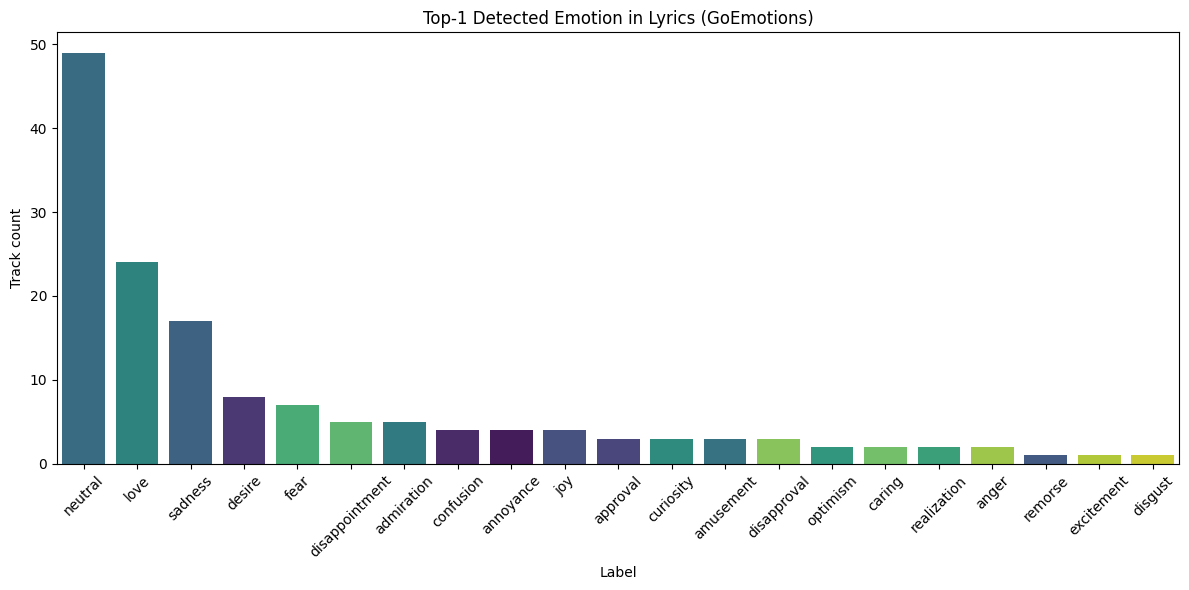

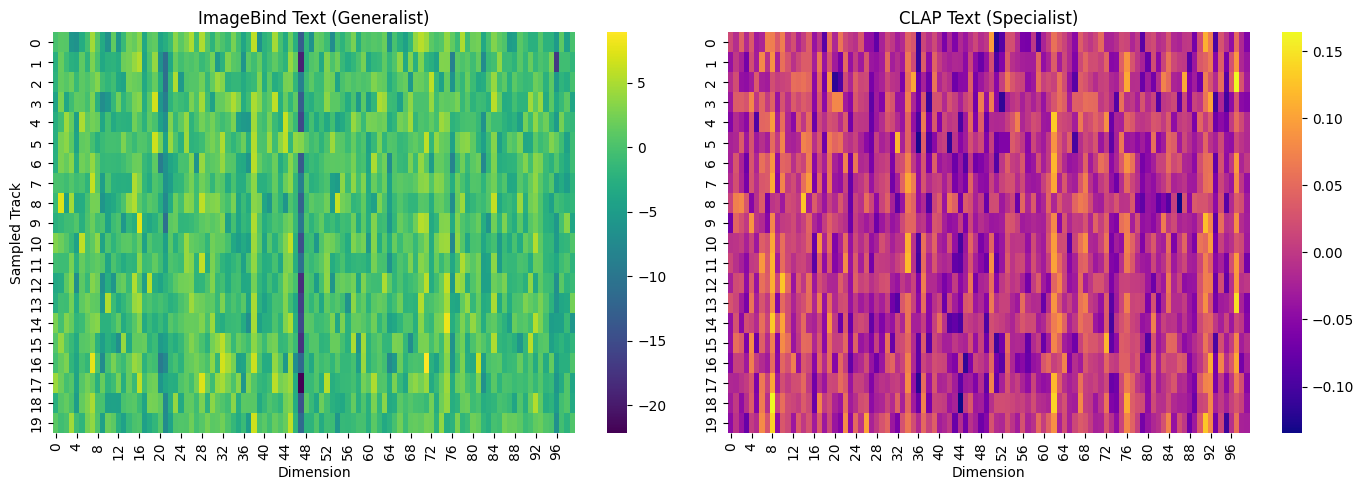

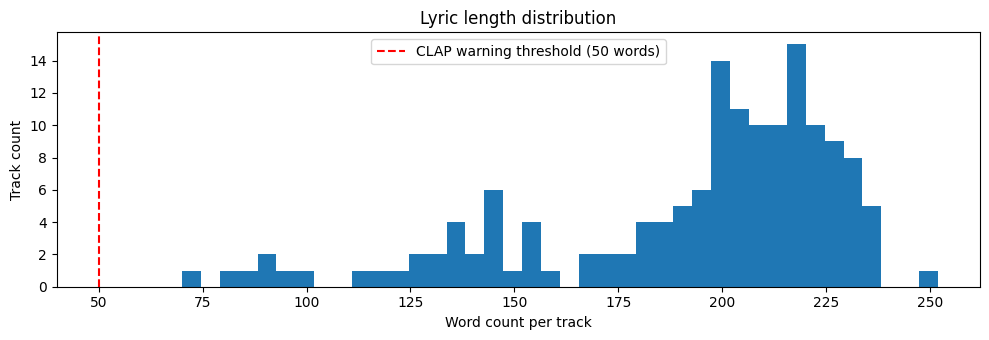

✅ Visual checks saved to /content/drive/MyDrive/DL_Project_2026/04_Visual_Checks/04_2026-04-24_21-32
✅ Notebook 04 complete.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Timestamped visual-check subfolder
stamp = datetime.now().strftime("%Y-%m-%d_%H-%M")
vis_out = os.path.join(VIS_DIR, f"{NOTEBOOK_ID}_{stamp}")
os.makedirs(vis_out, exist_ok=True)

text_ib   = np.load(os.path.join(EMBED_DIR, "text_ib_embeddings.npy"))
text_clap = np.load(os.path.join(EMBED_DIR, "text_clap_embeddings.npy"))

# ----- (a) Top-1 sentiment distribution -----
# hue='label' + legend=False sidesteps seaborn's `palette without hue` deprecation.
fig, ax = plt.subplots(figsize=(12, 6))
top1_order = sentiment_df["top1_label"].value_counts().index
sns.countplot(
    data=sentiment_df, x="top1_label",
    hue="top1_label", legend=False,
    palette="viridis", order=top1_order, ax=ax,
)
ax.set(title="Top-1 Detected Emotion in Lyrics (GoEmotions)", xlabel="Label", ylabel="Track count")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(os.path.join(vis_out, "text_sentiment_distribution.png"), dpi=150)
plt.show()

# ----- (b) Side-by-side IB-text vs CLAP-text heatmap (seeded random 20) -----
rng = np.random.RandomState(SEED)
idx = rng.choice(len(text_ib), size=20, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(text_ib[idx, :100],   ax=axes[0], cmap='viridis', cbar=True)
axes[0].set(title="ImageBind Text (Generalist)", xlabel="Dimension", ylabel="Sampled Track")
sns.heatmap(text_clap[idx, :100], ax=axes[1], cmap='plasma',  cbar=True)
axes[1].set(title="CLAP Text (Specialist)",      xlabel="Dimension")
fig.tight_layout()
fig.savefig(os.path.join(vis_out, "text_embedding_comparison.png"), dpi=150)
plt.show()

# ----- (c) Lyric length histogram with 50-word threshold -----
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.hist(lyric_stats["n_words"], bins=40)
ax.axvline(50, color="red", linestyle="--", label="CLAP warning threshold (50 words)")
ax.set(xlabel="Word count per track", ylabel="Track count", title="Lyric length distribution")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(vis_out, "lyric_lengths.png"), dpi=150)
plt.show()

print(f"✅ Visual checks saved to {vis_out}")
print("✅ Notebook 04 complete.")


In [ ]:
import os
lyrics_dir = os.path.join(PROCESSED_DIR, "lyrics")
print("lyrics dir exists:", os.path.exists(lyrics_dir))
print("num .txt files:", len([f for f in os.listdir(lyrics_dir) if f.endswith(".txt")]) if os.path.exists(lyrics_dir) else "N/A")
print("expected:", len(metadata))

lyrics dir exists: True
num .txt files: 150
expected: 150
